# Домашнее задание: Дерево принятия решений (Decision Tree) - Кредитный скоринг

## 🎯 Цели задания

1. Научиться строить дерево принятия решений для задачи классификации кредитных заявок.
2. Понять, как дерево принимает решения на основе признаков заемщика.
3. Научиться предобрабатывать данные с пропущенными значениями и категориальными признаками.
4. Оценить качество модели с помощью метрик классификации.
5. Понять, как переобучение проявляется в деревьях, и научиться с ним бороться.

## 📚 Теоретическая подготовка (рекомендуется)

Перед выполнением задания изучите:
- Принцип работы дерева решений (жадный алгоритм, критерии разбиения: Gini, Entropy).
- Как работает обучение и предсказание.
- Понятие переобучения и методы его снижения (ограничение глубины, min_samples_split и др.).
- Методы обработки пропущенных значений и кодирования категориальных признаков.

## 🧩 Задание

### Часть 1: Загрузка и предварительный анализ данных

In [29]:
# импорт необходимых библиотек
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [30]:
# загрузка датасета Loan Prediction Dataset (train.csv)
df = pd.read_csv('train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved
2,LN04186,Female,Yes,1,Not Graduate,Salaried,106981.515734,2229.154377,140550.937774,60,1,Rural,24.292070,Approved
3,LN00380,Male,Yes,2,Graduate,Salaried,43205.563156,35578.111771,146135.738127,120,1,Semiurban,38.742244,Approved
4,LN04698,Female,Yes,0,Graduate,Salaried,62526.283990,20212.157912,203408.051744,180,1,Semiurban,41.164721,Approved


Предварительный анализ данных

In [31]:
# типы данных, заполненность столбцов
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             3192 non-null   object 
 1   Gender              3115 non-null   object 
 2   Married             3126 non-null   object 
 3   Dependents          3192 non-null   int64  
 4   Education           3126 non-null   object 
 5   Employment_Status   3136 non-null   object 
 6   Applicant_Income    3157 non-null   float64
 7   Coapplicant_Income  3192 non-null   float64
 8   Loan_Amount         3151 non-null   float64
 9   Loan_Term           3192 non-null   int64  
 10  Credit_History      3192 non-null   int64  
 11  Property_Area       3192 non-null   object 
 12  Age                 3192 non-null   float64
 13  Loan_Status         3192 non-null   object 
dtypes: float64(4), int64(3), object(7)
memory usage: 349.3+ KB


In [32]:
# описательная статистика числовых признаков
df.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Age
count,3192.000000,3157.000000,3192.000000,3151.000000,3192.000000,3192.000000,3192.000000
mean,1.011905,59962.641490,15091.342368,151459.710168,212.368421,0.516917,35.201381
std,0.983975,19932.955795,9541.479521,50313.610809,101.428986,0.499792,7.722665
min,0.000000,15000.000000,0.000000,20000.000000,60.000000,0.000000,21.000000
25%,0.000000,46485.838417,7915.099793,116986.769053,120.000000,0.000000,29.853657
50%,1.000000,60290.179985,14608.469288,151967.787750,240.000000,1.000000,35.054461
75%,2.000000,73118.015531,21758.376019,186201.802079,300.000000,1.000000,40.537728
max,3.000000,138524.754129,47877.611874,373954.212551,360.000000,1.000000,61.159254


In [33]:
# пропуски в данных
print('Процентная доля пропусков в столбцах:')
print(df.isna().mean()*100)

Процентная доля пропусков в столбцах:
Loan_ID               0.000000
Gender                2.412281
Married               2.067669
Dependents            0.000000
Education             2.067669
Employment_Status     1.754386
Applicant_Income      1.096491
Coapplicant_Income    0.000000
Loan_Amount           1.284461
Loan_Term             0.000000
Credit_History        0.000000
Property_Area         0.000000
Age                   0.000000
Loan_Status           0.000000
dtype: float64


In [34]:
# названия столбцов
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Employment_Status', 'Applicant_Income', 'Coapplicant_Income',
       'Loan_Amount', 'Loan_Term', 'Credit_History', 'Property_Area', 'Age',
       'Loan_Status'],
      dtype='object')

In [35]:
cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Employment_Status',
    'Credit_History',
    'Property_Area',
    'Loan_Status'
    ]
print('Уникальные значения столбцов:')
for col in cols:
    print(f'{col}: {df[col].unique().tolist()}')

Уникальные значения столбцов:
Gender: ['Female', 'Male', nan]
Married: ['Yes', 'No', nan]
Dependents: [3, 1, 2, 0]
Education: ['Graduate', 'Not Graduate', nan]
Employment_Status: ['Salaried', 'Self-Employed', 'Unemployed', nan]
Credit_History: [1, 0]
Property_Area: ['Semiurban', 'Rural', 'Urban']
Loan_Status: ['Approved', 'Rejected']


In [36]:
# преобразование значений целевой переменной Loan_Status в числовые:
# 'Approved'→1, 'Rejected'→0
df['Loan_Status'] = df['Loan_Status'].map({'Approved' : 1, 'Rejected' : 0})
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,1
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,1
2,LN04186,Female,Yes,1,Not Graduate,Salaried,106981.515734,2229.154377,140550.937774,60,1,Rural,24.292070,1
3,LN00380,Male,Yes,2,Graduate,Salaried,43205.563156,35578.111771,146135.738127,120,1,Semiurban,38.742244,1
4,LN04698,Female,Yes,0,Graduate,Salaried,62526.283990,20212.157912,203408.051744,180,1,Semiurban,41.164721,1


In [37]:
# распределение значений целевой переменной Loan_Status
df['Loan_Status'].value_counts()

,count
Loan_Status,
1,1596
0,1596


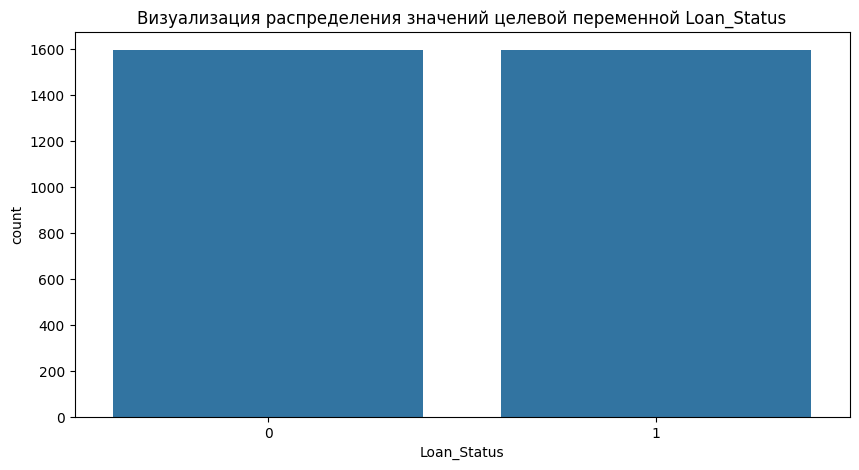

In [38]:
# визуализация распределения целевой переменной Loan_Status
plt.figure(figsize=(10,5))

sns.countplot(x='Loan_Status', data=df)

plt.title('Визуализация распределения значений целевой переменной Loan_Status')
plt.show()

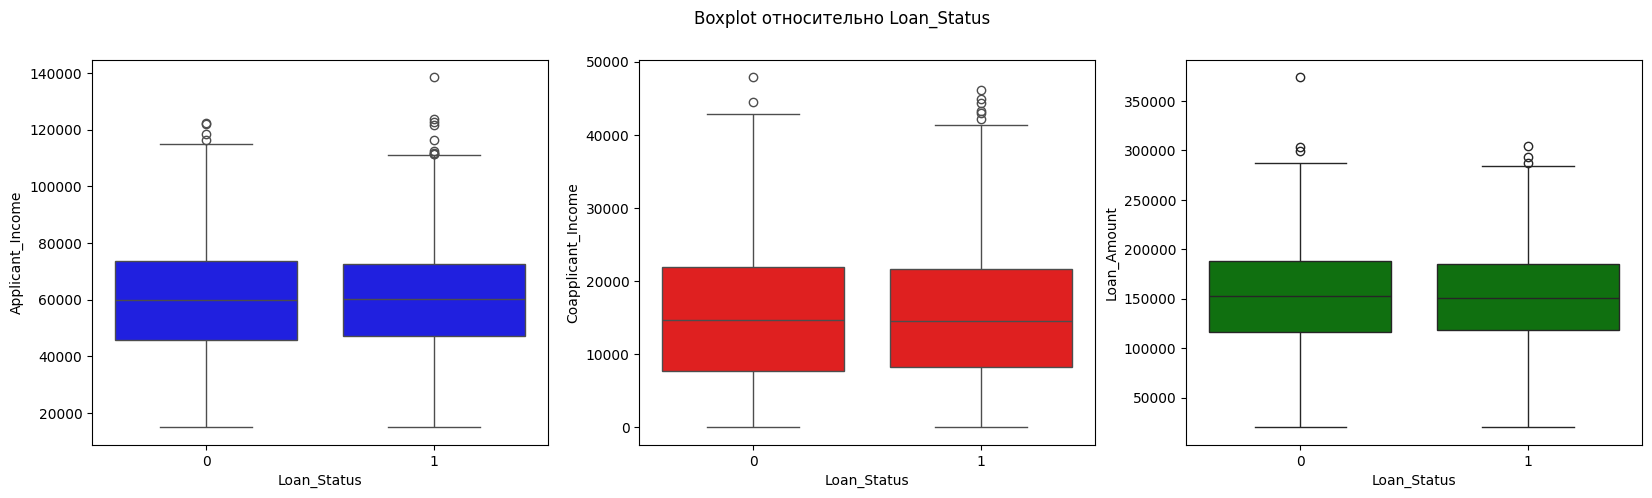

In [39]:
# Boxplot Applicant_Income, Coapplicant_Income, Loan_Amount относительно Loan_Status
fig, axes = plt.subplots(1, 3, figsize=(20,5))
fig.suptitle('Boxplot относительно Loan_Status')

sns.boxplot(
    x='Loan_Status',
    y='Applicant_Income',
    data=df,
    color='blue',
    ax=axes[0]
    )
sns.boxplot(
    x='Loan_Status',
    y='Coapplicant_Income',
    data=df,
    color='red',
    ax=axes[1]
    )
sns.boxplot(
    x='Loan_Status',
    y='Loan_Amount',
    data=df,
    color='green',
    ax=axes[2]
    )

plt.show()

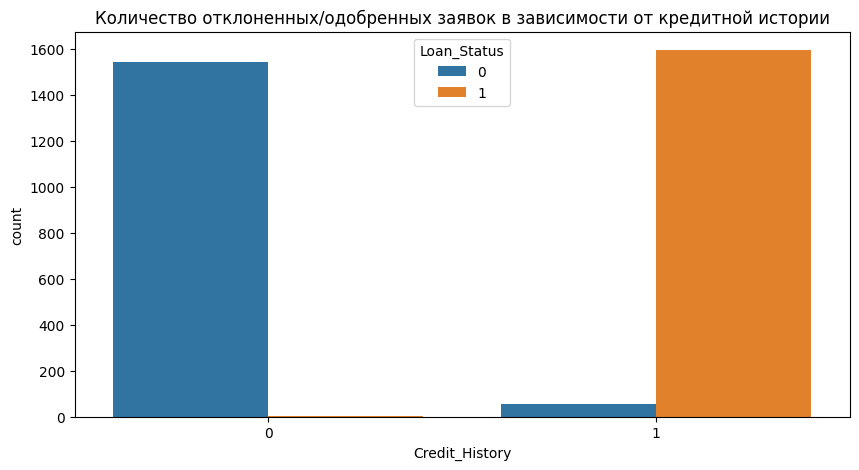

In [40]:
# визуализация влияния кредитной истории на одобрение кредита
plt.figure(figsize=(10,5))

sns.countplot(x='Credit_History', hue='Loan_Status', data=df)

plt.title('Количество отклоненных/одобренных заявок в зависимости от кредитной истории')
plt.show()

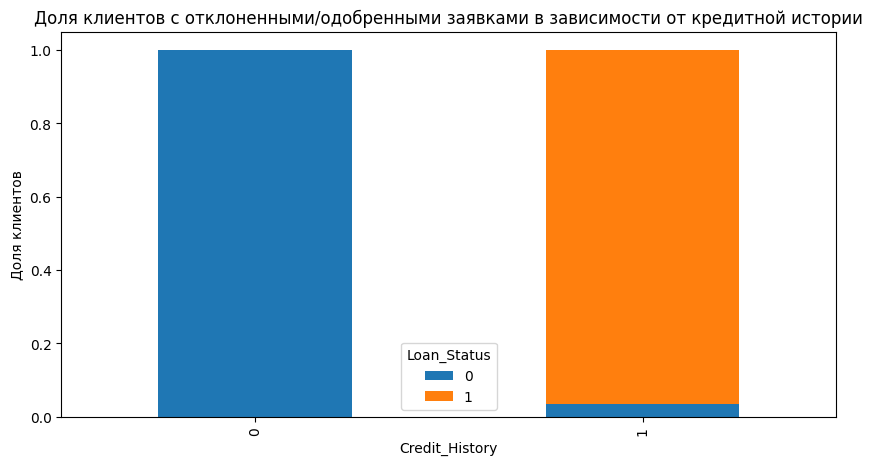

In [41]:
# визуализация влияния кредитной истории на одобрение кредита
approval_rate = pd.crosstab(
    df['Credit_History'],
    df['Loan_Status'],
    normalize='index'
)

approval_rate.plot(kind='bar', stacked=True, figsize=(10,5))

plt.ylabel('Доля клиентов')
plt.title('Доля клиентов с отклоненными/одобренными заявками в зависимости от кредитной истории')
plt.show()

In [42]:
# связь дохода заемщика Applicant_Income и одобрения кредита Loan_Status
df.groupby('Loan_Status')['Applicant_Income'].describe()

,count,mean,std,min,25%,50%,75%,max
Loan_Status,,,,,,,,
0,1578.0,59660.107614,20500.687248,15000.0,45630.579784,59827.678017,73651.036695,122258.204021
1,1579.0,60264.983769,19350.726506,15000.0,47037.856772,60420.076833,72723.109479,138524.754129


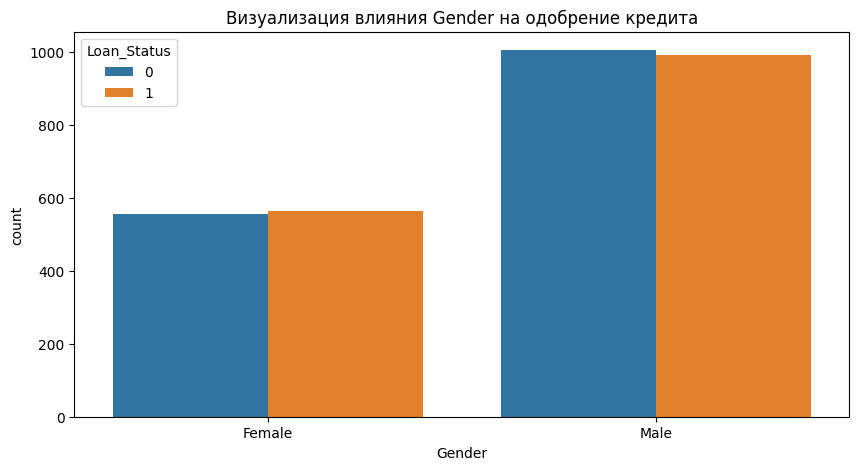

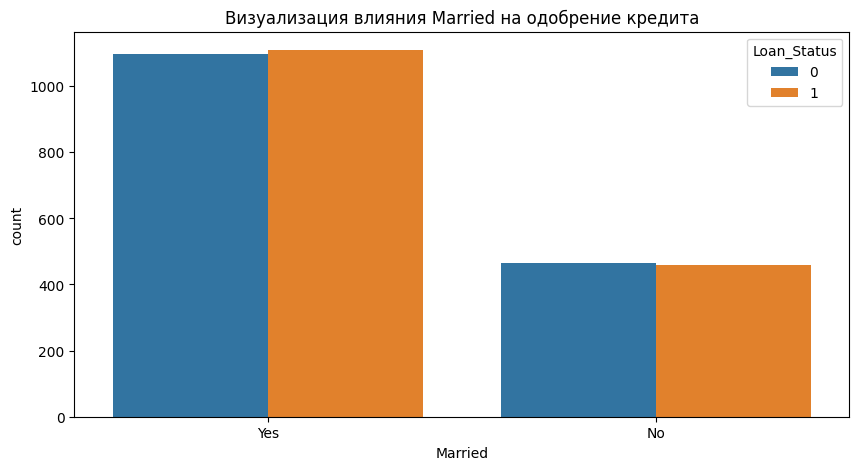

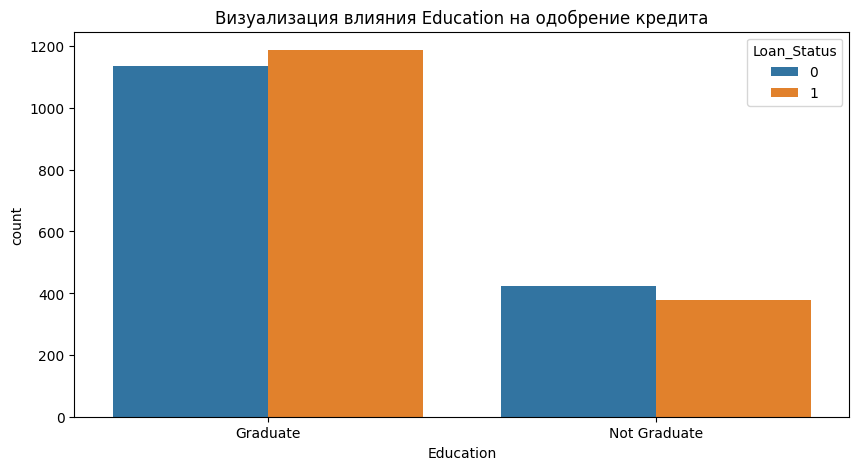

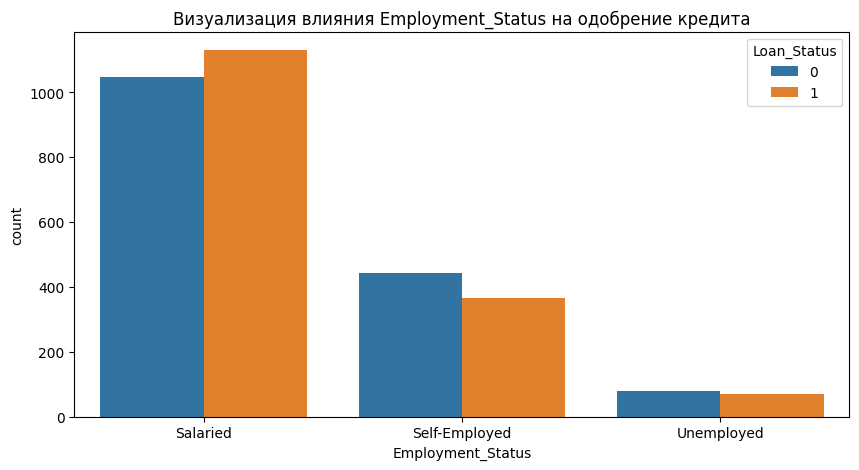

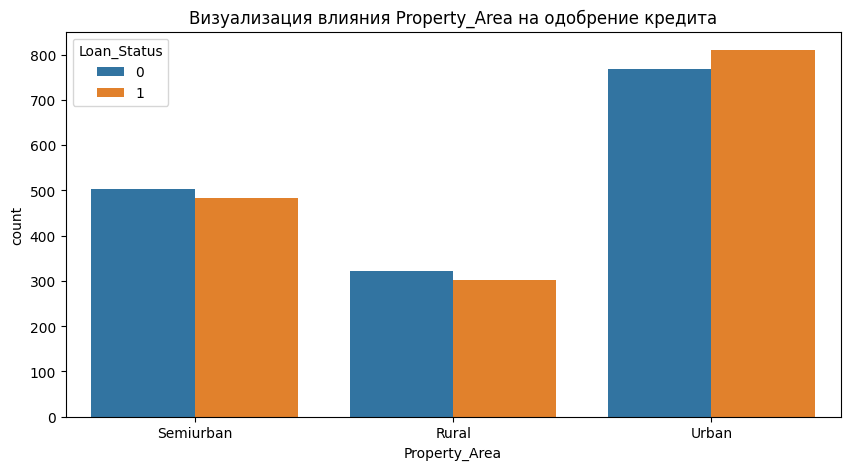

In [43]:
# визуализация влияния категориальных признаков на Loan_Status
cat_cols = list(df.select_dtypes(include='object').columns)
cat_cols.remove('Loan_ID')

for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(x=col, hue='Loan_Status', data=df)
    plt.title(f'Визуализация влияния {col} на одобрение кредита')
    plt.show()
    print()

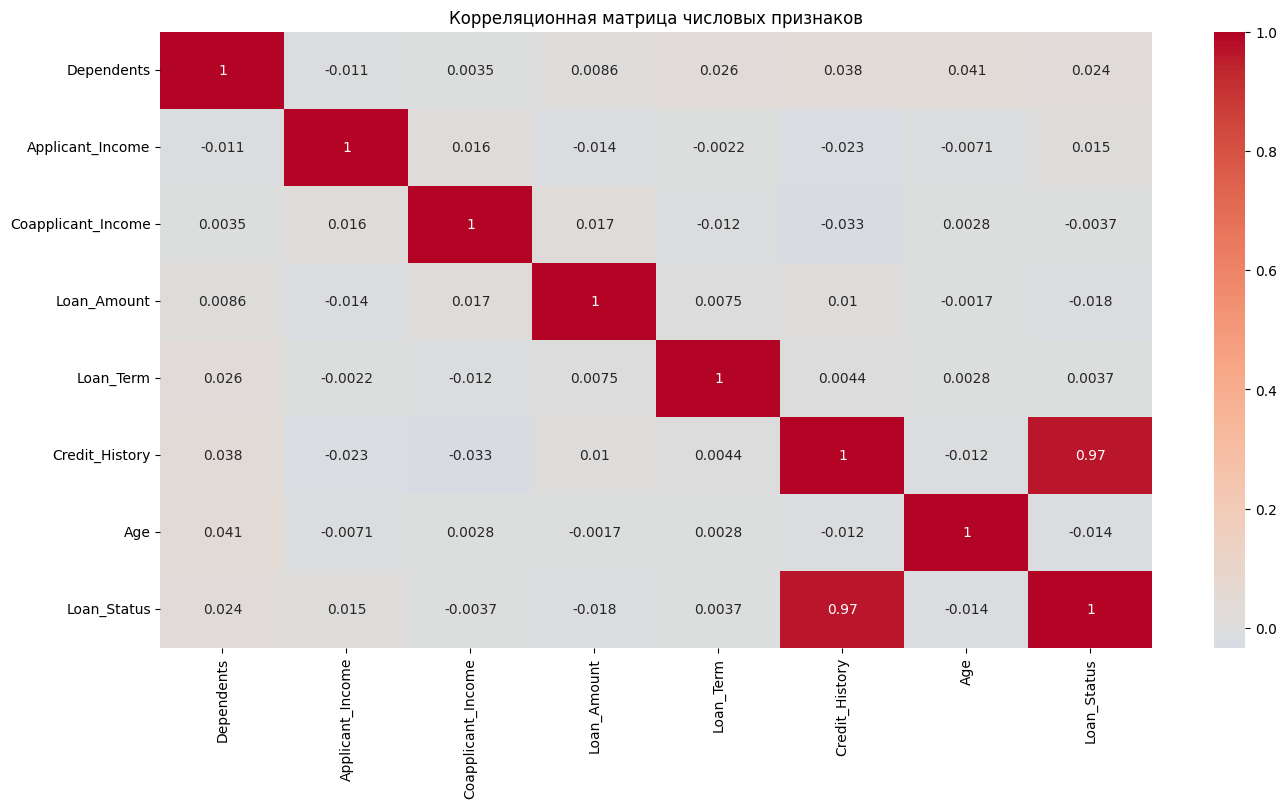

In [44]:
# корреляционная матрица числовых признаков
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(16,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Корреляционная матрица числовых признаков')
plt.show()

*Выводы на основании предварительного анализа данных:*

1.   Названия столбцов корректны, соответствуют содержимому признаков.
2.   Доля пропусков низкая. Несмотря на то, что дерево решений может работать с пропусками, они будут предварительно обработаны (заполнены).
3.  Явно некорректных и аномальных значений в стобцах не обнаружено.
4.  Целевая переменная распределена равномерно между классами одобренных и отклоненных заявок.
5.  Боксплоты признаков `Applicant_Income`, `Coapplicant_Income`, `Loan_Amount` относительно `Loan_Status` не выявили существенных различий между одобренными и отклоненными заявками, поэтому их влияние на целевую переменную может быть незначительным.
6.  Признак кредитной истории `Credit_History` имеет значительное влияние на одобрение кредита `Loan_Status`, между ними весьма высокая положительная корреляция. Вероятнее всего, что это ключевой фактор одобрения кредита.
7. Существенной мультиколлинеарности между числовыми признаками не наблюдается.
8. Более высокий доход заемщика `Applicant_Income` связан с небольшим увеличением вероятности одобрения кредита, однако данная зависимость выражена слабо.
9. По результатам предварительного анализа выявлено, что такие факторы, наличие хорошей кредитной истории, состояние в браке, наличие образования и наличие недвижимости в городской местности могут оказывать положительное влияние на вероятность одобрения кредита.

### Часть 2: Предобработка данных

In [45]:
# удаления столбца Loan_ID, который не несёт предсказательной информации
df = df.drop(columns='Loan_ID')

In [46]:
# разделение данных на признаки (X) и целевую переменную (y)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [47]:
# числовые столбцы с пропусками
num_cols = ['Applicant_Income', 'Loan_Amount']
# категориальные столбцы
cat_cols = ['Gender', 'Married', 'Education', 'Employment_Status', 'Property_Area']

# заполнение числовых пропусков медианой
# + создание индикатора наличия пропуска
num_transformer = SimpleImputer(strategy='median', add_indicator=True)

# заполнение категориальных пропусков наиболее частым значением
# + кодирование категориальных признаков
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

# предобработка признаков (признаки, не перечисленные в num_cols и cat_cols проходят без изменений)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
        ],
    remainder='passthrough',
    force_int_remainder_cols=False
    )

*Проведенная предобработка данных повышает качество исходного датасета:*
1. Удаление признака идентификатора, не несущий никакой предсказательной информации
2. Заполнение пропусков
3. Кодирование категориальных признаков, невоспринимаемых моделью, в числовые

### Часть 3: Построение базовой модели дерева решений

In [48]:
# обучение модели DecisionTreeClassifier с параметрами по умолчанию
dt_def_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
    ])
dt_def_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median'),
                                                  ['Applicant_Income',
                                                   'Loan_Amount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Education',
                                                   'Employment_Status',
                                                   'Property_Area'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [49]:
# предсказания на тестовой выборке
y_pred_test = dt_def_pipeline.predict(X_test)

# предсказания на обучающей выборке
y_pred_train = dt_def_pipeline.predict(X_train)

In [50]:
# оценка качества модели с помощью метрик
train_accuracy_def = accuracy_score(y_train, y_pred_train)
test_accuracy_def = accuracy_score(y_test, y_pred_test)
precision_def = precision_score(y_test, y_pred_test)
recall_def = recall_score(y_test, y_pred_test)
f1_def = f1_score(y_test, y_pred_test)

print('Метрики качества модели c параметрами по умолчанию:')
print(f'Train Accuracy:  {train_accuracy_def:.4f}')
print(f'Test Accuracy: - {test_accuracy_def:.4f}')
print(f'Precision: ----- {precision_def:.4f}')
print(f'Recall: -------- {recall_def:.4f}')
print(f'F1-score: ------ {f1_def:.4f}')

Метрики качества модели c параметрами по умолчанию:
Train Accuracy:  1.0000
Test Accuracy: - 0.9671
Precision: ----- 0.9599
Recall: -------- 0.9749
F1-score: ------ 0.9673


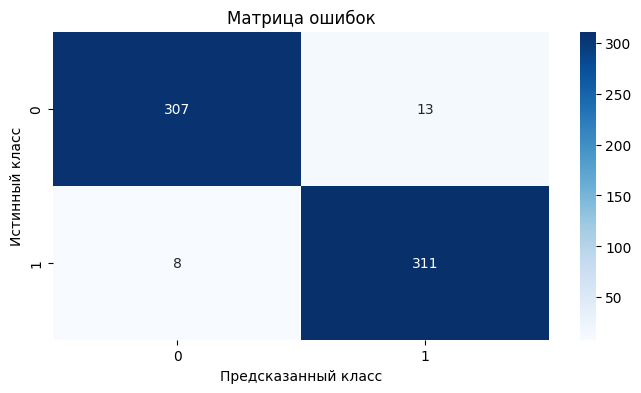

In [51]:
# построение и визуализация матрицы ошибок
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')

plt.show()

*Комментарий по построению базовой модели:*

1.   Полученная модель дерева решений показала весьма высокое качество на тестовой выборке:
*   Accuracy = 0.9671
*   Precision = 0.9599
*   Recall = 0.9749
*   F1-score = 0.9673

2.   Матрица ошибок показала малое ошибочных классификаций (21 объект из 639), значит, модель хорошо различает и выявляет одобренные и отклоненные заявки.


### Часть 4: Визуализация и интерпретация дерева решений

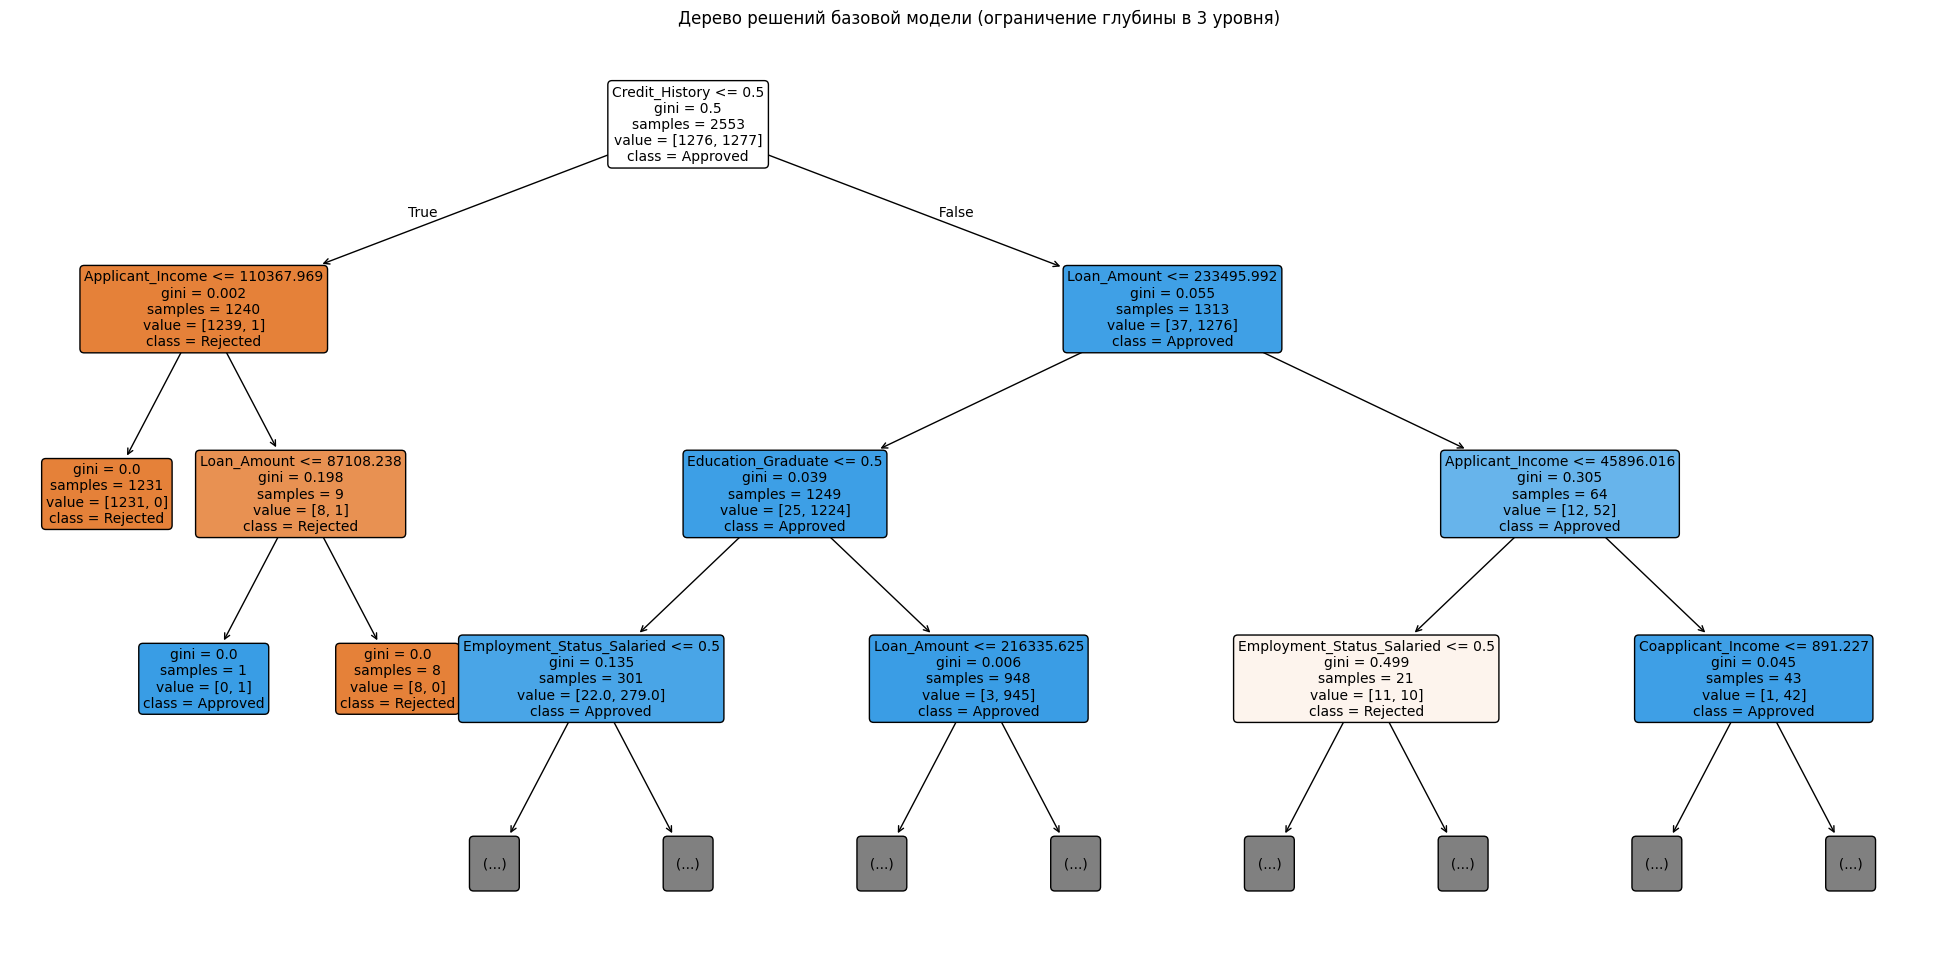

In [52]:
# получение названий признаков после предобработки
feature_names = dt_def_pipeline['preprocessor'].get_feature_names_out()
feature_names = [name.split('__', 1)[-1] for name in feature_names]

# визуализация построенного дерева с ограничением глубины в 3 уровня
plt.figure(figsize=(25,12))

plot_tree(
    dt_def_pipeline['classifier'],
    max_depth=3,
    feature_names=feature_names,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=10
    )
plt.title('Дерево решений базовой модели (ограничение глубины в 3 уровня)')
plt.show()

In [53]:
# важность признаков

feature_importances = dt_def_pipeline['classifier'].feature_importances_

feature_importances_df = pd.DataFrame({
    'feature' : feature_names,
    'importance' : feature_importances
})

feature_importances_df = feature_importances_df.sort_values(
    'importance',
    ascending=False
    )
feature_importances_df

,feature,importance
19,Credit_History,0.942097
0,Applicant_Income,0.014511
1,Loan_Amount,0.010551
17,Coapplicant_Income,0.007814
10,Employment_Status_Salaried,0.007252
15,Property_Area_Urban,0.005208
18,Loan_Term,0.003288
20,Age,0.002072
8,Education_Graduate,0.001750
14,Property_Area_Semiurban,0.001671


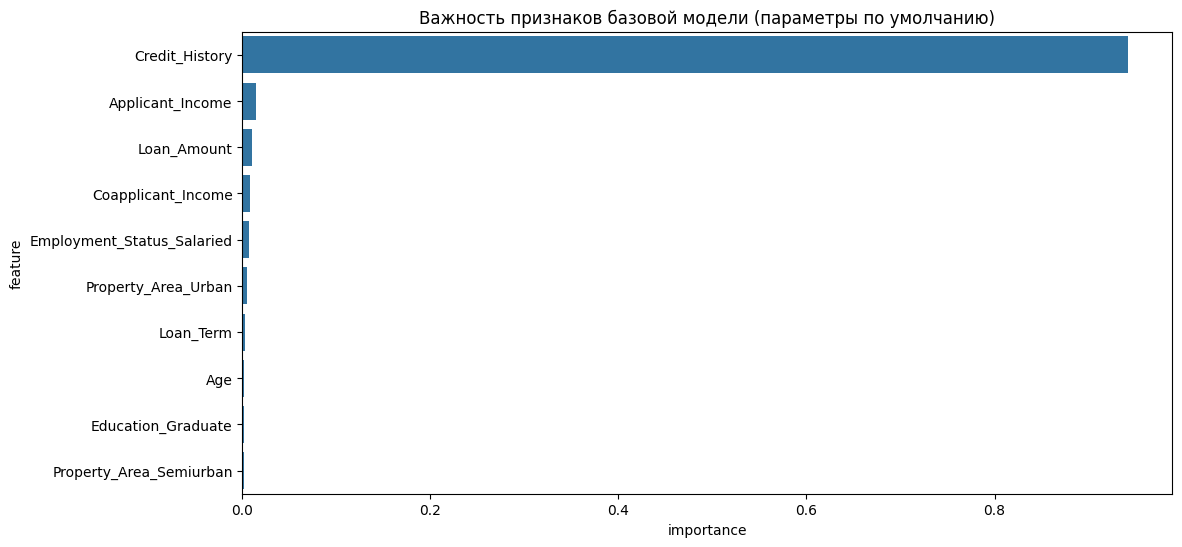

In [54]:
# визуализация наиболее значимых признаков базовой модели
plt.figure(figsize=(12,6))

sns.barplot(data=feature_importances_df.head(10), x='importance', y='feature')

plt.title('Важность признаков базовой модели (параметры по умолчанию)')
plt.show()

In [55]:
# проверка переобученности модели
print('Сравнение точности модели (Accuracy) на разных выборках:')
print(f'Train Accuracy: -------- {train_accuracy_def:.4f}')
print(f'Test Accuracy: --------- {test_accuracy_def:.4f}')
print(f'Разница Accuracy: ------ '
        f'{train_accuracy_def - test_accuracy_def:.2%}')

Сравнение точности модели (Accuracy) на разных выборках:
Train Accuracy: -------- 1.0000
Test Accuracy: --------- 0.9671
Разница Accuracy: ------ 3.29%


*Выводы по дереву решений базовой модели:*

1. Первое разделение произошло про признаку `Credit_History`, это значит, что модель в первую очередь анализирует кредитную историю заемщика.
2. Наиболее значимыми (топ-5) признаками базовой модели являются:
    * `Credit_History` (кредитная история)
    * `Applicant_Income` (доход заемщика)
    * `Loan_Amount` (сумма кредита)
    * `Coapplicant_Income` (доход созаемщика)
    * `Employment_Status_Salaried` (работа по найму)
    
    При этом вклад `Credit_History` значительно выше вклада остальных признаков вместе взятых.

3. Переобучение модели присутствует, об этом свидетельствует небольшая, но все же разница (3.29%) между `Train Accuracy = 1.0000` и `Test Accuracy = 0.9671`. То есть, модель идеально заучила обучающую выборку, что характерно для дерева решений без ограничений.
4. Выявленные из дерева решений закономерности:
    * наличие положительной кредитной истории - главное условие одобрения кредита
    * при отсутствии кредитной истории вероятность отказа в кредите очень высока
    * дополнительное влияние на вероятность выдачи кредита оказывают доход заемщика, сумма кредита, образование и статус занятости
    * заемщики с положительной кредитной историей чаще получают одобрение даже при различиях в остальных признаках
5. Дерево решение имеет высокую интерпретируемость, так как позволяет увидеть, какие признаки используются на каждом шаге разбиения, какие условия приводят к тому или иному решению по кредиту. По дереву решений можно проследить последовательность принятия решения.

### Часть 5: Оптимизация модели и борьба с переобучением

In [56]:
# обучение второй модели с ограничениями:
dt_cnst_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
        )
    )
    ])

dt_cnst_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median'),
                                                  ['Applicant_Income',
                                                   'Loan_Amount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Education',
                                                   'Employment_Status',
                                                   'Property_Area'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                        min_samples_split=20,
                                        random_state=42))])

In [57]:
# предсказания
y_pred_cnst_test = dt_cnst_pipeline.predict(X_test)
y_pred_cnst_train = dt_cnst_pipeline.predict(X_train)

In [60]:
# метрики качества модели с ограничениями
train_accuracy_cnst = accuracy_score(y_train, y_pred_cnst_train)
test_accuracy_cnst = accuracy_score(y_test, y_pred_cnst_test)
precision_cnst = precision_score(y_test, y_pred_cnst_test)
recall_cnst = recall_score(y_test, y_pred_cnst_test)
f1_cnst = f1_score(y_test, y_pred_cnst_test)

print('Метрики качества модели с ограничениями:')
print(f'Train Accuracy:  {train_accuracy_cnst:.4f}')
print(f'Test Accuracy: - {test_accuracy_cnst:.4f}')
print(f'Precision: ----- {precision_cnst:.4f}')
print(f'Recall: -------- {recall_cnst:.4f}')
print(f'F1-score: ------ {f1_cnst:.4f}')

Метрики качества модели с ограничениями:
Train Accuracy:  0.9875
Test Accuracy: - 0.9734
Precision: ----- 0.9494
Recall: -------- 1.0000
F1-score: ------ 0.9740


In [64]:
# таблица сравнения метрик базовой модели и модели с ограничениями
metrics_comparison_df = pd.DataFrame({
    'metrics' : ['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1'],
    'dt_model_with_default_parameters' : [
        train_accuracy_def,
        test_accuracy_def,
        precision_def,
        recall_def,
        f1_def
        ],
    'dt_model_with_constraints' : [
        train_accuracy_cnst,
        test_accuracy_cnst,
        precision_cnst,
        recall_cnst,
        f1_cnst
        ]
})
metrics_comparison_df.round(4)

,metrics,dt_model_with_default_parameters,dt_model_with_constraints
0,Train Accuracy,1.0000,0.9875
1,Test Accuracy,0.9671,0.9734
2,Precision,0.9599,0.9494
3,Recall,0.9749,1.0000
4,F1,0.9673,0.9740


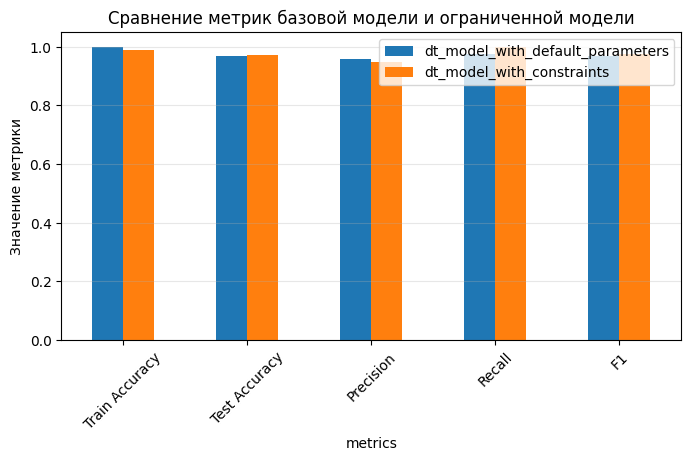

In [62]:
# визуализация сравнения метрик базовой модели и модели с ограничениями
metrics_comparison_df.set_index('metrics').plot(kind='bar', figsize=(8,4))

plt.title('Сравнение метрик базовой модели и ограниченной модели')
plt.ylabel('Значение метрики')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

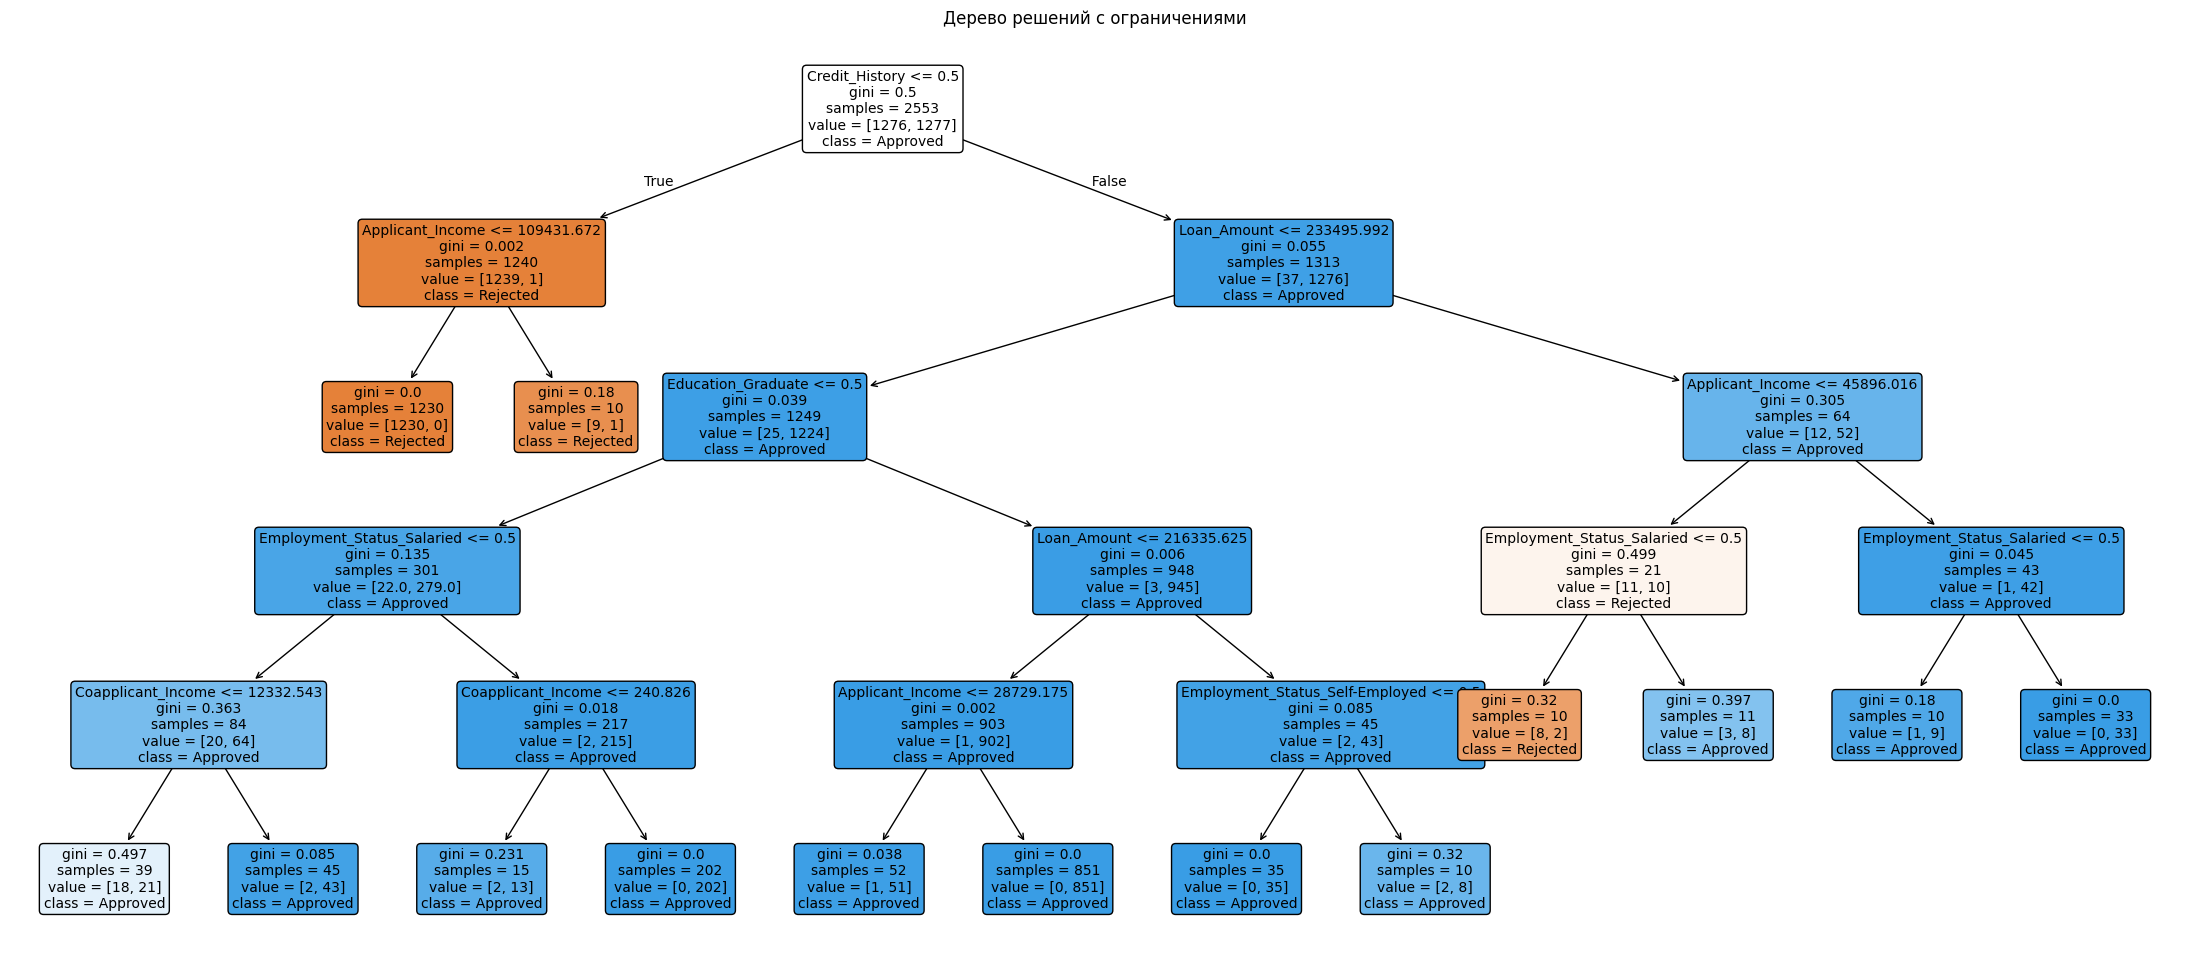

In [63]:
feature_names_cnst = dt_cnst_pipeline['preprocessor'].get_feature_names_out()
feature_names_cnst = [name.split('__', 1)[-1] for name in feature_names_cnst]

# визуализация дерева c ограничениями
plt.figure(figsize=(28,12))

plot_tree(
    dt_cnst_pipeline['classifier'],
    feature_names=feature_names_cnst,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=10
    )

plt.title('Дерево решений с ограничениями')
plt.show()

*Подробный комментарий о том, как ограничения повлияли на качество модели и помогли ли они справиться с переобучением*

Введенные ограничения `max_depth=5, min_samples_split=20, min_samples_leaf=10`:
1. Немного улучшили качество модели, так как выросли `F1: 0.9673 -> 0.9740` и `Recall: 0.9749 -> 1.0000`, что означает уменьшение числа случаев, когда модель ошибочно отклоняет одобряемые в реальности заявки.
2. Помогли справиться с переобучением модели, так как точность на обучающей выборке снизилась `Train Accuracy: 1.0000 -> 0.9875`, а точность на тестовой выборке чуть выросла `Test Accuracy: 0.9671 -> 0.9734`. Модель теперь лучше обобщает данные и меньше зависит от особенностей обучающей выборки.

Введение ограничений в модель позволило снизить переобучение дерева решений, при этом даже с улучшением качества на тестовой выборке. Ограниченная модель является более устойчивой и предпочтительной для применения.

### Часть 6: Дополнительный анализ и выводы

In [65]:
# значимость признаков для модели с ограничениями
feature_importances_cnst = dt_cnst_pipeline['classifier'].feature_importances_

feature_importances_df_cnst = pd.DataFrame({
    'feature' : feature_names_cnst,
    'importance' : feature_importances_cnst
})

feature_importances_df_cnst = feature_importances_df_cnst.sort_values(
    'importance',
    ascending=False
    )
feature_importances_df_cnst

,feature,importance
19,Credit_History,0.974938
10,Employment_Status_Salaried,0.007629
17,Coapplicant_Income,0.006296
0,Applicant_Income,0.005922
1,Loan_Amount,0.002899
8,Education_Graduate,0.001811
11,Employment_Status_Self-Employed,0.000504
2,missingindicator_Applicant_Income,0.000000
3,missingindicator_Loan_Amount,0.000000
4,Gender_Female,0.000000


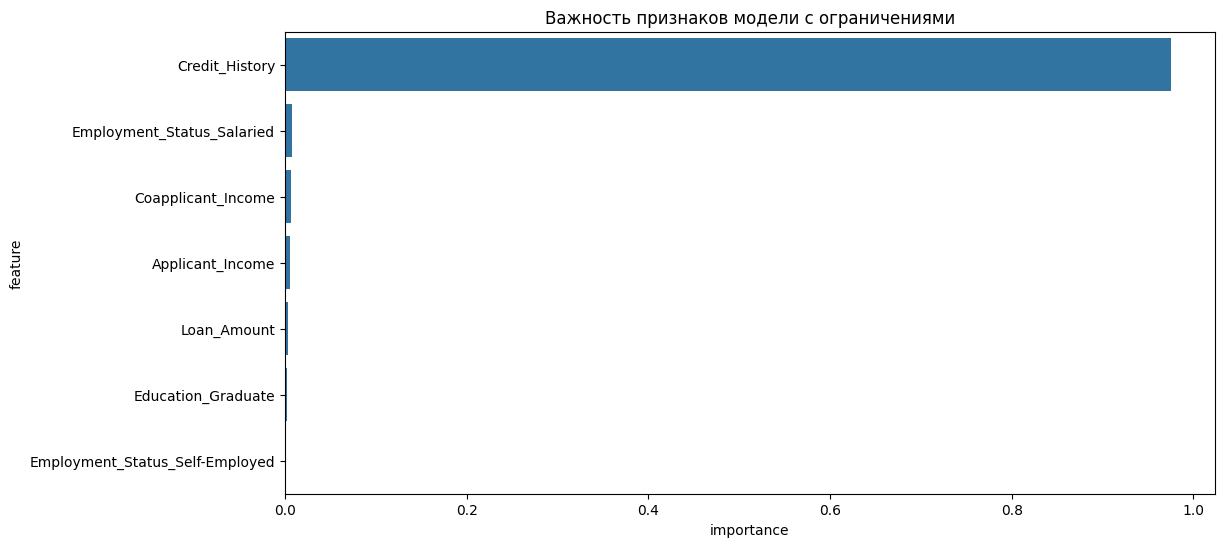

In [66]:
# визуализация наиболее значимых признаков модели с ограничениями
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importances_df_cnst.head(7),
    x='importance',
    y='feature'
    )

plt.title('Важность признаков модели с ограничениями')
plt.show()

Наиболее значимыми (топ-5) признаками оптимизированной модели являются:
1. Credit_History (кредитная история)
2. Employment_Status_Salaried (работа по найму)
3. Coapplicant_Income (доход созаемщика)
4. Applicant_Income (доход заемщика)
5. Loan_Amount (сумма кредита)

**ВЫВОДЫ ПО РАБОТЕ.**

1. Наиболее значимым признаком для одобрения кредита в обоих моделях является `Credit_History` (кредитная история заемщика), его важность (`importance`) очень близка к единице и после регуляризации даже выросла `с 0.9421 до 0,9750`. То есть, модель практически полностью опирается на информацию о наличии положительной кредитной истории заемщика при принятии решения.
2. Важности остальных топ-признаков для моделей немного различаются, но набор этих признаков одинаковый, и помимо кредитной истории, на решение по заявке на кредит влияют доходы заемщика `Applicant_Income` и созаемщика `Coapplicant_Income`, сумма кредита `Loan_Amount`, фактор работы по найму `Employment_Status_Salaried`.
3. При решении данной задачи проявились следующие преимущества дерева решений:
    * отсутствие необходимости масштабирования признаков
    * достаточно хорошое качество модели даже с параметрами по умолчанию (метрики `Accuracy, Precision, Recall, F1` имеют высокие значения)
    * возможность визуализации дерева
    * высокая интерпретируемость - можно достаточно легко проследить процесс принятия решения
    * дерево автоматически определяет наиболее важные признаки

    и недостатки:
    * склонность к переобучению при отсутствии ограничений (`Train Accuracy = 1.000` у базовой модели в данной задаче)
    * высокая чувствительность к отдельным сильным признакам (в данной задаче обе модели практически полностью опираются на кредитную историю `Credit_History`)
4. Возможные пути дальнейшего улучшения модели:
    * подобрать гиперпараметры дерева решений с помощью `GridSearchCV`
    * провести кросс-валидацию для более устойчивой оценки качества
    * провести инженерию признаков и создать новые информативные признаки
    * использовать ансамблевые методы: `Random Forest, Gradient Boosting, XGBoost`